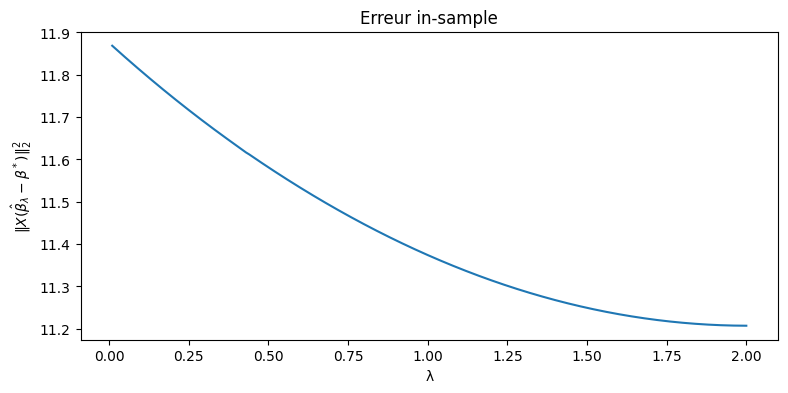

λ optimal (in-sample) = 2.00


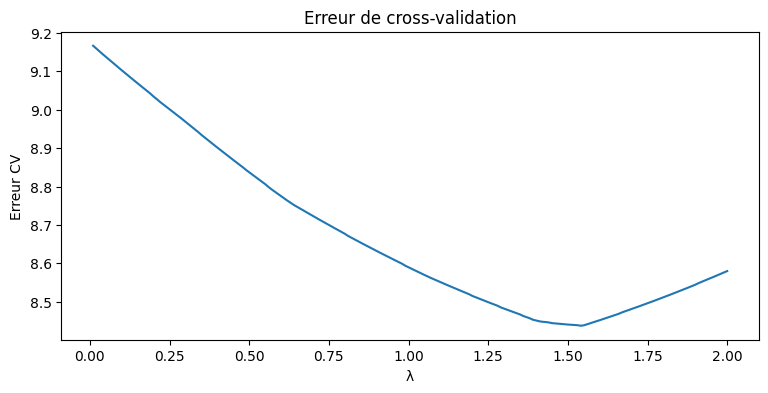

λ optimal (Cross-Validation) = 1.54
λ optimal (in-sample) = 2.00


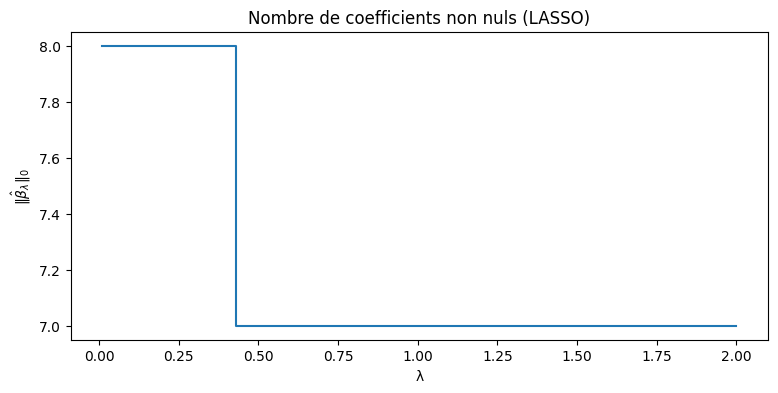

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import Lasso
from sklearn.model_selection import KFold

# Question 1
np.random.seed(42)
n_samples = 20
dim = 8
X = np.random.standard_normal((n_samples, dim))
beta_star = np.array([5, 3, 0, 0, 1.5, 0, 0, 0])
eps = np.random.standard_normal(n_samples)
Y = X @ beta_star + eps

lam_grid = np.arange(0.01, 2.01, 0.01)

# Question 2
def lasso_fit(X, Y, lam):
    # alpha = lam / (2*n) dans sklearn (convention)
    model = Lasso(alpha=lam / (2 * len(Y)), fit_intercept=False, max_iter=10000)
    model.fit(X, Y)
    return model.coef_

err_lam = np.array([
    np.linalg.norm(X @ (lasso_fit(X, Y, lam) - beta_star))**2
    for lam in lam_grid
])

plt.figure(figsize=(9, 4))
plt.plot(lam_grid, err_lam)
plt.xlabel("λ")
plt.ylabel(r"$\|X(\hat{\beta}_\lambda - \beta^*)\|_2^2$")
plt.title("Erreur in-sample")
plt.show()

lambda_opt = lam_grid[np.argmin(err_lam)]
print(f"λ optimal (in-sample) = {lambda_opt:.2f}")

# Question 3
kf = KFold(n_splits=5, shuffle=True, random_state=0)
cv_errors = []

for lam in lam_grid:
    err = 0
    for train_idx, val_idx in kf.split(X):
        X_train, X_val = X[train_idx], X[val_idx]
        Y_train, Y_val = Y[train_idx], Y[val_idx]

        beta = lasso_fit(X_train, Y_train, lam)
        err += np.linalg.norm(X_val @ beta - Y_val)**2
    cv_errors.append(err / kf.get_n_splits())

plt.figure(figsize=(9, 4))
plt.plot(lam_grid, cv_errors)
plt.xlabel("λ")
plt.ylabel("Erreur CV")
plt.title("Erreur de cross-validation")
plt.show()

lambda_cv = lam_grid[np.argmin(cv_errors)]
print(f"λ optimal (Cross-Validation) = {lambda_cv:.2f}")
print(f"λ optimal (in-sample) = {lambda_opt:.2f}")

# Question 4
def l0_norm(beta, eps=1e-8):
    return np.sum(np.abs(beta) > eps)

beta_l0 = np.array([l0_norm(lasso_fit(X, Y, lam)) for lam in lam_grid])

plt.figure(figsize=(9, 4))
plt.step(lam_grid, beta_l0)
plt.xlabel("λ")
plt.ylabel(r"$\|\hat{\beta}_\lambda\|_0$")
plt.title("Nombre de coefficients non nuls (LASSO)")
plt.show()